# Build a Financial Analyst Tool-Use AI Agent

This project will focus on building a Tool-Use Agentic AI System which acts as a Financial Analyst & Advisor.

![](https://i.imgur.com/sHevAT8.png)


### Financial Analyst Tool-Use Agentic AI System

In this project, we will design a **Financial Analyst Tool-Use Agentic AI System** to assist investors with accurate, up-to-date stock market insights. We will be building the complete agent from scratch using **LangGraph**, a cutting-edge alternative to LangChain. The workflow comprises the following components:

1. **Agent System Prompt**:
   - The agent is designed to validate input queries for relevance and specificity.
   - It provides comprehensive market analysis or stock-specific insights depending on the user's query.
   - For invalid queries, the agent responds professionally and guides the user appropriately.


   **Flows**:
   - **Flow 1**: For general market trends, the agent analyzes data and suggests stock opportunities using tools like `SEARCH_WEB` and `GET_GENERAL_MARKET_DATA`.
   - **Flow 2**: For stock-specific queries, the agent validates the stock ticker, retrieves relevant data, and provides insights using tools such as `GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS` and `GET_STOCK_PRICE_METRICS`.

2. **Financial Analysis Tools**:
   The system integrates multiple tools to get useful financial data and metrics:
   - **SEARCH_WEB**: Fetches general stock market information from the web.
   - **GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS**: Provides insights into key financial metrics such as P/E ratio, ROE, etc.
   - **GET_STOCK_NEWS**: Extracts the latest news and updates related to stocks or markets.
   - **GET_GENERAL_MARKET_DATA**: Fetches data on overall market trends and performance.
   - **GET_STOCK_TICKER**: Validates and fetches stock ticker symbols based on user queries.
   - **GET_STOCK_PRICE_METRICS**: Retrieves price trends, performance, and metrics for specific stocks.

3. **Stock Market Data Providers**:
   The system ensures real-time, reliable data by integrating with top providers like Yahoo Finance, Finviz, TMX, Cboe, and more, through platforms like **OpenBB**.

4. **Message Trimmer**:
   A newly introduced component trims agent state message history to ensure they are well within the context window limit of the LLM.

5. **Tool-Use Agentic Framework**:
   The system employs **ReAct reasoning**, combining logical reasoning with dynamic tool usage. This framework ensures precise and actionable results by dynamically selecting the right tools based on the query.

6. **Final Response**:
   After processing the data from tool calls, the agentic system generates the final response.



## Install OpenAI, LangGraph and LangChain dependencies

In [2]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.64
# fix yfinance to stable version
!pip install yfinance==0.2.58

  Using cached yfinance-0.2.58-py2.py3-none-any.whl.metadata (5.5 kB)
Using cached yfinance-0.2.58-py2.py3-none-any.whl (113 kB)
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.51
    Uninstalling yfinance-0.2.51:
      Successfully uninstalled yfinance-0.2.51


## Install OpenBB

In [3]:
!pip install openbb

## Enter Open AI API Key

In [4]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

## Enter OpenBB Key

Get a free API key from [here](https://my.openbb.co/app/platform/pat)

In [5]:
from getpass import getpass

OPENBB_PAT = getpass('Enter OpenBB Personal Access Token (PAT): ')

## Enter Tavily Search API Key

Get a free API key from [here](https://tavily.com/#api)

In [6]:
TAVILY_API_KEY = getpass('Enter Tavily Search API Key: ')

## Setup Environment Variables

In [26]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY
os.environ['TAVILY_API_KEY'] = TAVILY_API_KEY
os.environ["FMP_API_KEY"] = "uEYlJVRp5oUtkP9k9AMwHuqyJfnGcghd"


In [20]:
from openbb import obb

# takes 1 min to setup
# obb.account.login(pat=OPENBB_PAT)
obb.user.credentials.fmp_api_key = ""
obb.user.credentials.polygon_api_key = ""
obb.user.credentials.benzinga_api_key = ""

## Create Financial Tools

**Financial Analysis Tools**:
   The system integrates multiple tools to get useful financial data and metrics:
   - **SEARCH_WEB**: Fetches general stock market information from the web.
   - **GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS**: Provides insights into key financial metrics such as P/E ratio, ROE, etc.
   - **GET_STOCK_NEWS**: Extracts the latest news and updates related to stocks or markets.
   - **GET_GENERAL_MARKET_DATA**: Fetches data on overall market trends and performance.
   - **GET_STOCK_TICKER**: Validates and fetches stock ticker symbols based on user queries.
   - **GET_STOCK_PRICE_METRICS**: Retrieves price trends, performance, and metrics for specific stocks.

In [39]:
# COMPLETE WORKING SOLUTION - Replace all financial tool functions with these:

from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_core.tools import tool
import json
import requests
from tqdm import tqdm
from bs4 import BeautifulSoup
from datetime import datetime, timedelta

tavily_search = TavilySearchAPIWrapper()

@tool
def search_web(query: str, num_results=8) -> list:
    """Search the web for a query. Useful for general information or general news"""
    results = tavily_search.raw_results(query=query,
                                        max_results=num_results,
                                        search_depth='advanced',
                                        include_answer=False,
                                        include_raw_content=True)
    return results

@tool
def get_stock_ticker_symbol(stock_name: str) -> str:
    """Get the symbol, name and CIK for any publicly traded company"""
    try:
        res = obb.equity.search(stock_name, provider="sec")
        stock_ticker_details = res.to_df().to_markdown()
        output = """Here are the details of the company and its stock ticker symbol:\n\n""" + stock_ticker_details
    except Exception as e:
        output = f"Error fetching stock ticker: {str(e)}"
    return output

@tool
def get_stock_price_metrics(stock_ticker: str) -> str:
    """Get historical stock price data, stock price quote and price performance data
       like price changes for a specific stock ticker"""
    
    try:
        # Use yfinance for quote
        res = obb.equity.price.quote(stock_ticker, provider='yfinance')
        price_quote = res.to_df().to_markdown()
    except Exception as e:
        price_quote = f"Could not fetch price quote: {str(e)}"
    
    try:
        # Use FMP for performance if available, otherwise skip
        res = obb.equity.price.performance(symbol=stock_ticker, provider='fmp')
        price_performance = res.to_df().to_markdown()
    except:
        # If FMP fails, calculate basic performance from historical data
        try:
            end_date = datetime.now()
            start_date = (end_date - timedelta(days=365)).strftime("%Y-%m-%d")
            res = obb.equity.price.historical(symbol=stock_ticker, start_date=start_date,
                                              interval='1d', provider='yfinance')
            df = res.to_df()
            if len(df) > 0:
                latest_price = df['close'].iloc[-1]
                year_ago_price = df['close'].iloc[0]
                pct_change = ((latest_price - year_ago_price) / year_ago_price) * 100
                price_performance = f"1-Year Performance: {pct_change:.2f}%"
            else:
                price_performance = "Performance data not available"
        except Exception as e:
            price_performance = f"Could not calculate performance: {str(e)}"
    
    try:
        # Historical price data for past year using yfinance
        end_date = datetime.now()
        start_date = (end_date - timedelta(days=365)).strftime("%Y-%m-%d")
        res = obb.equity.price.historical(symbol=stock_ticker, start_date=start_date,
                                          interval='1d', provider='yfinance')
        price_historical = res.to_df().tail(10).to_markdown()  # Last 10 days only
    except Exception as e:
        price_historical = f"Could not fetch historical data: {str(e)}"
    
    output = (f"""Here are the stock price metrics and data for the stock ticker symbol {stock_ticker}: \n\n"""
              f"Price Quote Metrics:\n\n{price_quote}\n\n"
              f"Price Performance:\n\n{price_performance}\n\n"
              f"Recent Price History (Last 10 Days):\n\n{price_historical}")
    return output

@tool
def get_stock_fundamental_indicator_metrics(stock_ticker: str) -> str:
    """Get fundamental indicator metrics for a specific stock ticker"""
    
    try:
        # Use yfinance for metrics
        res = obb.equity.fundamental.metrics(symbol=stock_ticker, period='annual',
                                            limit=5, provider='yfinance')
        fundamental_metrics = res.to_df().to_markdown()
    except Exception as e:
        fundamental_metrics = f"Could not fetch fundamental metrics: {str(e)}"
    
    output = ("""Here are the fundamental indicator metrics and data for the stock ticker symbol """ + stock_ticker + """: \n\n""" +
              "Fundamental Metrics:\n\n" + fundamental_metrics)
    return output

@tool
def get_stock_news(stock_ticker: str) -> str:
    """Get news article headlines for a specific stock ticker"""
    
    # Define the date range to fetch news (last 30 days)
    end_date = datetime.now()
    start_date = (end_date - timedelta(days=30)).strftime("%Y-%m-%d")
    
    try:
        # Use yfinance provider
        res = obb.news.company(symbol=stock_ticker, start_date=start_date, 
                               provider='yfinance', limit=20)
        news = res.to_df()
        
        # Extract relevant columns
        if 'title' in news.columns:
            if 'date' in news.columns:
                news_formatted = news[['date', 'title']].to_markdown()
            else:
                news_formatted = news[['title']].to_markdown()
        else:
            news_formatted = news.to_markdown()
    except Exception as e:
        news_formatted = f"Could not fetch news: {str(e)}"
    
    output = ("""Here are the recent news headlines for the stock ticker symbol """ + stock_ticker + """: \n\n""" + news_formatted)
    return output

@tool
def get_general_market_data() -> str:
    """Get general data and indicators for the whole stock market including,
       most actively traded stocks based on volume, top price gainers and top price losers.
       Useful when you want an overview of the market and what stocks to look at."""
    
    try:
        res = obb.equity.discovery.active(sort='desc', provider='yfinance', limit=15)
        most_active_stocks = res.to_df().to_markdown()
    except Exception as e:
        most_active_stocks = f"Could not fetch active stocks: {str(e)}"
    
    try:
        res = obb.equity.discovery.gainers(sort='desc', provider='yfinance', limit=15)
        price_gainers = res.to_df().to_markdown()
    except Exception as e:
        price_gainers = f"Could not fetch gainers: {str(e)}"
    
    try:
        res = obb.equity.discovery.losers(sort='desc', provider='yfinance', limit=15)
        price_losers = res.to_df().to_markdown()
    except Exception as e:
        price_losers = f"Could not fetch losers: {str(e)}"
    
    output = ("""Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:\n\n""" +
              "Most actively traded stocks:\n\n" + most_active_stocks +
              "\n\nTop price gainers:\n\n" + price_gainers +
              "\n\nTop price losers:\n\n" + price_losers)
    return output

## Try out Defined Tools

In [40]:
!pip install tabulate

In [41]:
from IPython.display import display, Markdown

response = get_general_market_data.invoke({})
display(Markdown(response))

Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:

Most actively traded stocks:

|    | symbol   | name                       |   price |     change |   percent_change |    volume |    open |    high |    low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:---------------------------|--------:|-----------:|-----------------:|----------:|--------:|--------:|-------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | NVDA     | NVIDIA Corporation         |  190.17 |  3.31      |       0.0177138  | 186591856 | 182.86  | 191.01  | 180.58 |           186.86 | 185.608  | 151.191   |     212.19  |     86.62  |  4.63007e+12 |          2.4347e+10  |        4.113 |        46.2363  |      3.52 |          4.12 |     46.1578  |      0.000214064 | NMS        | America/New_York    | 2025-11-19 16:00:00-05:00 | USD        |
|  1 | OPEN     | Opendoor Technologies Inc  |    8.12 | -0.44      |      -0.0514018  | 184137397 |   8.08  |   8.96  |   7.85 |             8.56 |   7.9883 |   3.11862 |      10.87  |      0.508 |  8.16132e+09 |          9.53426e+08 |        1.051 |         7.72598 |     -0.44 |         -0.27 |    -30.0741  |      0           | NMS        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
|  2 | TSLA     | Tesla, Inc.                |  404.35 |  2.35999   |       0.00587076 | 105506682 | 386.24  | 412.19  | 382.78 |           401.99 | 429.668  | 338.496   |     488.54  |    214.25  |  1.3448e+12  |          3.32582e+09 |       24.058 |        16.8073  |      1.46 |          3.24 |    124.799   |      0           | NMS        | America/New_York    | 2025-10-22 16:00:00-04:00 | USD        |
|  3 | PFE      | Pfizer, Inc.               |   25.06 | -0.730001  |      -0.0283056  |  96241626 |  25.67  |  25.77  |  24.97 |            25.79 |  24.7942 |  24.5918  |      27.69  |     20.92  |  1.46634e+11 |          5.68571e+09 |       16.321 |         1.53545 |      1.72 |          2.93 |      8.5529  |      0.065917    | NYQ        | America/New_York    | 2025-11-04 08:30:00-05:00 | USD        |
|  4 | BBAI     | BigBear.ai, Inc.           |    6.06 | -0.28      |      -0.0441641  |  90364293 |   6.1   |   6.6   |   6.02 |             6.34 |   6.6842 |   5.38035 |      10.36  |      1.7   |  2.76773e+09 |          4.36551e+08 |        1.4   |         4.32857 |     -1.45 |         -0.2  |    -30.3     |      0           | NYQ        | America/New_York    | 2025-11-10 16:00:00-05:00 | USD        |
|  5 | SOFI     | SoFi Technologies, Inc.    |   27.82 | -0.57      |      -0.0200775  |  87118512 |  27     |  29.07  |  26.53 |            28.39 |  28.1172 |  19.1939  |      32.73  |      8.6   |  3.42356e+10 |          1.2059e+09  |        7.289 |         3.81671 |      0.56 |          0.29 |     95.931   |      0           | NMS        | America/New_York    | 2025-10-28 08:30:00-04:00 | USD        |
|  6 | NU       | Nu Holdings Ltd.           |   15.82 |  0.23      |       0.014753   |  82474256 |  15.43  |  16.26  |  15.32 |            15.59 |  15.6786 |  13.1882  |      16.55  |      9.01  |  7.53364e+10 |          3.78175e+09 |        2.178 |         7.26354 |      0.52 |          0.62 |     25.5161  |      0           | NYQ        | America/New_York    | 2025-11-13 16:00:00-05:00 | USD        |
|  7 | ACHR     | Archer Aviation Inc.       |    7.88 | -0.0799999 |      -0.0100502  |  74688954 |   7.74  |   8.23  |   7.63 |             7.96 |  10.267  |   9.60575 |      14.62  |      4.05  |  5.18468e+09 |          6.51342e+08 |        2.54  |         3.10236 |     -1.17 |         -0.99 |     -7.9596  |      0           | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
|  8 | INTC     | Intel Corporation          |   35.52 | -0.389999  |      -0.0108605  |  71716180 |  35.01  |  36.1   |  34.62 |            35.91 |  34.6332 |  25.0535  |      42.48  |     17.67  |  1.71291e+11 |          4.77e+09    |       22.32  |         1.5914  |      0.06 |          0.97 |     36.6186  |      0           | NMS        | America/New_York    | 2025-10-23 16:00:00-04:00 | USD        |
|  9 | F        | Ford Motor Company         |   13.19 | -0.0900002 |      -0.00677712 |  67885132 |  13.18  |  13.31  |  13.1  |            13.28 |  12.2938 |  10.9033  |      13.97  |      8.44  |  5.29141e+10 |          3.91365e+09 |       11.894 |         1.10896 |      1.17 |          1.75 |      7.53714 |      0.0451807   | NYQ        | America/New_York    | 2025-10-23 16:00:00-04:00 | USD        |
| 10 | PLTR     | Palantir Technologies Inc. |  174.01 |  1.87      |       0.0108632  |  62596757 | 166.975 | 177.29  | 164.5  |           172.14 | 180.473  | 137.93    |     207.52  |     58.85  |  4.10285e+11 |          2.28433e+09 |        2.765 |        62.9331  |      0.1  |          0.47 |    370.234   |      0           | NMS        | America/New_York    | 2025-11-03 16:00:00-05:00 | USD        |
| 11 | RIVN     | Rivian Automotive, Inc.    |   15.11 | -1.28      |      -0.0780964  |  60069182 |  15.7   |  15.87  |  15.07 |            16.39 |  14.1748 |  13.2742  |      18.13  |      9.85  |  2.00927e+10 |          1.222e+09   |        4.132 |         3.65682 |     -3.1  |         -2.74 |     -5.5146  |      0           | NMS        | America/New_York    | 2025-11-04 16:00:00-05:00 | USD        |
| 12 | CIFR     | Cipher Mining Inc.         |   14.36 | -0.57      |      -0.0381781  |  56948156 |  13.94  |  15.76  |  13.55 |            14.93 |  16.1838 |   7.35115 |      25.52  |      1.86  |  5.90078e+09 |          3.95092e+08 |        1.99  |         7.21608 |     -0.17 |          0    |    nan       |      0           | NMS        | America/New_York    | 2025-11-03 08:30:00-05:00 | USD        |
| 13 | SNAP     | Snap Inc.                  |    8.57 | -0.0100002 |      -0.00116553 |  56628645 |   8.35  |   8.655 |   8.31 |             8.58 |   7.9862 |   8.59435 |      13.281 |      6.9   |  1.47521e+10 |          1.46521e+09 |        1.302 |         6.58218 |     -0.29 |          0.41 |     20.9024  |      0           | NYQ        | America/New_York    | 2025-11-05 16:00:00-05:00 | USD        |
| 14 | NIO      | NIO Inc.                   |    6.16 | -0.0799999 |      -0.0128205  |  53493970 |   5.99  |   6.3   |   5.95 |             6.24 |   6.9858 |   4.95475 |       8.02  |      3.02  |  1.61711e+10 |          2.31568e+09 |       -0.537 |       -11.4711  |     -1.62 |         -0.85 |     -7.24706 |      0           | NYQ        | America/New_York    | 2025-11-25 08:30:00-05:00 | USD        |

Top price gainers:

|    | symbol   | name                            |   price |   change |   percent_change |   volume |    open |    high |     low |   previous_close |     ma50 |    ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:--------------------------------|--------:|---------:|-----------------:|---------:|--------:|--------:|--------:|-----------------:|---------:|---------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | SRRK     | Scholar Rock Holding Corporatio |   37.41 |     7.34 |        0.244097  |  7132707 | 34.7554 | 39.5    | 34.25   |            30.07 | 32.4487  | 33.6458  |     46.98   |     22.71  |  3.59612e+09 |          9.61273e+07 |        2.47  |       15.1457   |     -2.92 |         -2.15 |    -17.4     |        0         | NMS        | America/New_York    | 2025-11-14 08:30:00-05:00 | USD        |
|  1 | LGN      | Legence Corp.                   |   40.27 |     6.95 |        0.208583  |  2814211 | 35      | 42.04   | 35      |            33.32 | 34.0975  | 34.0975  |     43.82   |     26.96  |  3.50498e+09 |          5.85106e+07 |      nan     |      nan        |      0.33 |        nan    |    nan       |        0         | NMS        | America/New_York    | 2025-11-14 08:30:00-05:00 | USD        |
|  2 | CTKB     | Cytek Biosciences, Inc.         |    5.5  |     0.93 |        0.203501  |  6944566 |  4.9992 |  5.78   |  4.71   |             4.57 |  4.022   |  3.88405 |      7.3    |      2.37  |  7.03257e+08 |          1.27865e+08 |        2.961 |        1.85748  |     -0.11 |          0.06 |     91.6667  |        0         | NMS        | America/New_York    | 2025-11-05 16:00:00-05:00 | USD        |
|  3 | CSIQ     | Canadian Solar Inc.             |   33.58 |     4.96 |        0.173305  | 11751498 | 27.374  | 34.59   | 26.8    |            28.62 | 16.737   | 12.0633  |     34.59   |      6.57  |  2.24893e+09 |          6.69722e+07 |       42.417 |        0.791664 |     -0.19 |          2.89 |     11.6194  |        0         | NMS        | America/New_York    | 2025-11-13 08:30:00-05:00 | USD        |
|  4 | FIGR     | Figure Technology Solutions, In |   40.24 |     5.65 |        0.163342  |  5207779 | 35.5    | 43.62   | 35.4671 |            34.59 | 40.1132  | 40.1132  |     49.5    |     30.01  |  7.40204e+09 |          1.76101e+08 |        5.489 |        7.33103  |      0.27 |        nan    |    nan       |        0         | NMS        | America/New_York    | 2025-11-13 16:00:00-05:00 | USD        |
|  5 | ANGX     | Angel Studios, Inc.             |    5.98 |     0.73 |        0.139048  |  1100027 |  5.25   |  6.02   |  5.0639 |             5.25 |  7.12553 |  7.12553 |     20.385  |      3.77  |  8.43542e+08 |          8.99993e+07 |        0.103 |       58.0583   |     -0.66 |        nan    |    nan       |        0         | NYQ        | America/New_York    | nan                       | USD        |
|  6 | EWTX     | Edgewise Therapeutics, Inc.     |   22.75 |     2.33 |        0.114104  |  2512837 | 20.52   | 23.62   | 19.96   |            20.42 | 16.113   | 17.0748  |     35.5    |     10.6   |  2.40851e+09 |          1.05868e+08 |        5.282 |        4.30708  |     -1.57 |         -1.85 |    -12.2973  |        0         | NMS        | America/New_York    | 2025-11-06 08:30:00-05:00 | USD        |
|  7 | IMOS     | ChipMOS TECHNOLOGIES INC.       |   30.82 |     2.93 |        0.105056  |    74604 | 29.4    | 30.9813 | 29.4    |            27.89 | 20.5762  | 18.5585  |     30.9813 |     12.78  |  1.07164e+09 |          3.47709e+07 |       33.389 |        0.923059 |      1.32 |          1.01 |     30.5148  |        0.0430262 | NMS        | America/New_York    | 2025-11-11 08:30:00-05:00 | USD        |
|  8 | FLNC     | Fluence Energy, Inc.            |   17.91 |     1.66 |        0.102154  | 10086658 | 15.315  | 18.27   | 15.22   |            16.25 | 14.7885  |  8.5083  |     24      |      3.46  |  2.96573e+09 |          1.31007e+08 |        3.113 |        5.75329  |     -0.18 |          0.65 |     27.5538  |        0         | NMS        | America/New_York    | 2025-11-24 16:00:00-05:00 | USD        |
|  9 | ARQT     | Arcutis Biotherapeutics, Inc.   |   25    |     2.14 |        0.0936133 |  3954003 | 22.28   | 25.2    | 22.26   |            22.86 | 20.5803  | 15.9449  |     27.079  |      8.9   |  3.0623e+09  |          1.22492e+08 |        1.314 |       19.0259   |     -0.34 |         -0.98 |    -25.5102  |        0         | NMS        | America/New_York    | 2025-10-28 08:30:00-04:00 | USD        |
| 10 | ELVN     | Enliven Therapeutics, Inc.      |   22.07 |     1.8  |        0.0888011 |   565729 | 19.88   | 22.32   | 19.84   |            20.27 | 20.2316  | 20.0606  |     26.48   |     13.3   |  1.3098e+09  |          5.93473e+07 |        8.034 |        2.74707  |     -1.81 |         -2.37 |     -9.31224 |        0         | NMS        | America/New_York    | nan                       | USD        |
| 11 | TERN     | Terns Pharmaceuticals, Inc.     |   22.56 |     1.83 |        0.0882779 |  3930186 | 20.58   | 23.31   | 20.3    |            20.73 | 10.1182  |  5.6668  |     23.31   |      1.865 |  2.0322e+09  |          9.00798e+07 |        3.246 |        6.95009  |     -1.02 |         -1.39 |    -16.2302  |        0         | NMS        | America/New_York    | 2025-11-10 16:00:00-05:00 | USD        |
| 12 | CGON     | CG Oncology, Inc.               |   41.01 |     3.25 |        0.0860699 |  1408575 | 38      | 41.73   | 37.285  |            37.76 | 39.5443  | 29.1825  |     45.559  |     14.8   |  3.12691e+09 |          7.62476e+07 |        8.785 |        4.66818  |     -2.05 |         -1.78 |    -23.0393  |        0         | NMS        | America/New_York    | 2025-11-14 08:30:00-05:00 | USD        |
| 13 | MSIF     | MSC Income Fund, Inc.           |   13.13 |     1.01 |        0.0833333 |   353321 | 12.27   | 13.2    | 12.145  |            12.12 | 13.208   | 15.2873  |     18.095  |     11.78  |  6.22894e+08 |          4.74405e+07 |       15.529 |        0.845515 |      1.39 |        nan    |    nan       |        0         | NYQ        | America/New_York    | nan                       | USD        |
| 14 | INVX     | Innovex International, Inc.     |   22.08 |     1.65 |        0.0807636 |   740661 | 20.95   | 22.48   | 20.67   |            20.43 | 18.7044  | 16.8514  |     22.48   |     11.93  |  1.52193e+09 |          6.89278e+07 |       15.074 |        1.46477  |      0.64 |          0.77 |     28.6753  |        0         | NYQ        | America/New_York    | 2025-11-03 16:00:00-05:00 | USD        |

Top price losers:

|    | symbol   | name                            |   price |     change |   percent_change |   volume |   open |     high |     low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:--------------------------------|--------:|-----------:|-----------------:|---------:|-------:|---------:|--------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | AVNT     | Avient Corporation              |   29.29 |  -0.859999 |       -0.028524  |   618019 |  29.61 |  30.045  |  29.105 |            30.15 |  32.6914 |  35.5236  |       53.61 |      27.86 |  2.76064e+09 |          9.15636e+07 |       25.911 |         1.13041 |      1.23 |          2.95 |      9.92881 |       0.0358209  | NYQ        | America/New_York    | 2025-11-05 08:30:00-05:00 | USD        |
|  1 | AGM      | Federal Agricultural Mortgage C |  164.13 |  -4.81999  |       -0.0285291 |    60440 | 168.43 | 168.344  | 164.09  |           168.95 | 170.101  | 184.072   |      217.14 |     155    |  1.78127e+09 |          9.37364e+06 |      107.828 |         1.52215 |     17.55 |         17.63 |      9.3097  |       0.0349216  | NYQ        | America/New_York    | 2025-11-03 16:00:00-05:00 | USD        |
|  2 | SMG      | Scotts Miracle-Gro Company (The |   56.73 |  -1.67     |       -0.0285959 |   511216 |  57.88 |  58.34   |  56.455 |            58.4  |  57.0778 |  60.0765  |       83.55 |      45.61 |  3.37193e+09 |          5.77386e+07 |       -6.196 |        -9.15591 |      2.47 |          4.24 |     13.3797  |       0.0452055  | NYQ        | America/New_York    | 2025-11-05 08:30:00-05:00 | USD        |
|  3 | BVS      | Bioventus Inc.                  |    7.35 |  -0.22     |       -0.0290621 |   252006 |   7.51 |   7.51   |   7.235 |             7.57 |   6.981  |   7.62255 |       12.61 |       5.81 |  5.07012e+08 |          6.69765e+07 |        2.48  |         2.96371 |      0.16 |          0.66 |     11.1364  |       0          | NMS        | America/New_York    | 2025-11-04 08:30:00-05:00 | USD        |
|  4 | XYZ      | Block, Inc.                     |   60.48 |  -1.82     |       -0.0292135 |  9142873 |  61.03 |  62.185  |  60.17  |            62.3  |  74.5786 |  68.3325  |       99.26 |      44.27 |  3.78575e+10 |          5.47667e+08 |       36.943 |         1.63712 |      4.97 |        nan    |    nan       |       0          | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
|  5 | PHVS     | Pharvaris N.V.                  |   23.55 |  -0.709999 |       -0.0292662 |   360937 |  24.36 |  25.045  |  23.48  |            24.26 |  23.1953 |  19.1866  |       26.33 |      11.51 |  1.57458e+09 |          6.49595e+07 |        5.045 |         4.66799 |     -3.37 |         -3.05 |     -7.72131 |       0          | NMS        | America/New_York    | 2025-11-12 08:30:00-05:00 | USD        |
|  6 | FSCO     | nan                             |    6.27 |  -0.19     |       -0.0294118 |  2714016 |   6.4  |   6.47   |   6.26  |             6.46 |   6.8108 |   7.0175  |        7.65 |       5.29 |  1.28138e+09 |          1.98356e+08 |      nan     |       nan       |      0.9  |        nan    |    nan       |       0          | NYQ        | America/New_York    | nan                       | USD        |
|  7 | AEBI     | Aebi Schmidt Holding AG         |   10.87 |  -0.33     |       -0.0294643 |   353344 |  11.2  |  11.37   |  10.7   |            11.2  |  11.791  |  11.4507  |       33    |       8.91 |  8.66228e+08 |          7.73418e+07 |       10.554 |         1.02994 |      0.17 |        nan    |    nan       |       0.00223214 | NMS        | America/New_York    | 2025-11-13 08:30:00-05:00 | USD        |
|  8 | RHI      | Robert Half Inc.                |   26.67 |  -0.809999 |       -0.029476  |  2379931 |  27.31 |  27.49   |  26.55  |            27.48 |  31.4874 |  42.7576  |       78.41 |      25.22 |  2.77991e+09 |          1.01161e+08 |       12.874 |         2.07162 |      1.54 |          2.93 |      9.10239 |       0.0836972  | NYQ        | America/New_York    | 2025-10-22 16:00:00-04:00 | USD        |
|  9 | IHS      | IHS Holding Limited             |    6.24 |  -0.19     |       -0.029549  |  1333094 |   6.06 |   6.41   |   5.71  |             6.43 |   6.785  |   5.74145 |        8    |       2.61 |  2.1574e+09  |          3.35521e+08 |       -0.405 |       -15.4074  |      1.38 |          0.2  |     31.2     |       0          | NYQ        | America/New_York    | 2025-11-12 08:30:00-05:00 | USD        |
| 10 | CWH      | Camping World Holdings, Inc.    |   10.81 |  -0.33     |       -0.029623  |  1421026 |  11.07 |  11.08   |  10.69  |            11.14 |  15.1652 |  16.6663  |       25.97 |      10.69 |  6.9981e+08  |          6.28196e+07 |        4.715 |         2.29268 |     -1    |          0.96 |     11.2604  |       0.0448833  | NYQ        | America/New_York    | 2025-10-28 16:00:00-04:00 | USD        |
| 11 | ZS       | Zscaler, Inc.                   |  299.45 |  -9.14999  |       -0.02965   |  2170822 | 303.76 | 306.975  | 292.18  |           308.6  | 305.329  | 262.065   |      336.99 |     164.78 |  4.88516e+10 |          1.58301e+08 |       11.366 |        26.3461  |     -0.27 |          3.56 |     84.1152  |       0          | NMS        | America/New_York    | 2025-11-25 16:00:00-05:00 | USD        |
| 12 | ASH      | Ashland Inc.                    |   51.51 |  -1.59     |       -0.0299435 |   561005 |  52.47 |  52.8999 |  50.97  |            53.1  |  49.9124 |  53.1968  |       80.94 |      45.21 |  2.42699e+09 |          4.5706e+07  |       41.391 |         1.24447 |    -17.98 |          5.73 |      8.98953 |       0.0308851  | NYQ        | America/New_York    | 2025-11-04 16:00:00-05:00 | USD        |
| 13 | BROS     | Dutch Bros Inc.                 |   53.71 |  -1.66     |       -0.0299801 |  2663218 |  54.29 |  55.18   |  53.28  |            55.37 |  55.7912 |  63.5667  |       86.88 |      46.53 |  9.10959e+09 |          1.27031e+08 |        5.168 |        10.3928  |      0.49 |          0.54 |     99.463   |       0          | NYQ        | America/New_York    | 2025-11-05 16:00:00-05:00 | USD        |
| 14 | SYK      | Stryker Corporation             |  362.22 | -11.2      |       -0.0299931 |  1903529 | 371.82 | 373.41   | 362.15  |           373.42 | 371.999  | 378.763   |      406.19 |     329.16 |  1.42805e+11 |          3.82424e+08 |       56.966 |         6.35853 |      7.61 |         13.53 |     26.7716  |       0.00899791 | NYQ        | America/New_York    | 2025-10-30 16:00:00-04:00 | USD        |

In [42]:
response = get_stock_ticker_symbol.invoke('Nvidia')
display(Markdown(response))

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |

In [43]:
response = get_stock_price_metrics.invoke('NVDA')
display(Markdown(response))

Here are the stock price metrics and data for the stock ticker symbol NVDA: 

Price Quote Metrics:

|    | symbol   | asset_type   | name               | exchange   |    bid |   bid_size |   ask |   ask_size |   last_price |   open |   high |    low |    volume |   prev_close |   year_high |   year_low |   ma_50d |   ma_200d |   volume_average |   volume_average_10d | currency   |
|---:|:---------|:-------------|:-------------------|:-----------|-------:|-----------:|------:|-----------:|-------------:|-------:|-------:|-------:|----------:|-------------:|------------:|-----------:|---------:|----------:|-----------------:|---------------------:|:-----------|
|  0 | NVDA     | EQUITY       | NVIDIA Corporation | NMS        | 189.45 |          1 | 190.6 |          1 |       190.17 | 182.86 | 191.01 | 180.58 | 186591856 |       186.86 |      212.19 |      86.62 |  185.608 |   151.191 |      1.84551e+08 |          1.95227e+08 | USD        |

Price Performance:

1-Year Performance: 35.69%

Recent Price History (Last 10 Days):

| date       |   open |   high |    low |   close |      volume |   dividend |
|:-----------|-------:|-------:|-------:|--------:|------------:|-----------:|
| 2025-11-03 | 208.08 | 211.34 | 205.56 |  206.88 | 1.80267e+08 |          0 |
| 2025-11-04 | 203    | 203.97 | 197.93 |  198.69 | 1.88919e+08 |          0 |
| 2025-11-05 | 198.77 | 202.92 | 194.65 |  195.21 | 1.7135e+08  |          0 |
| 2025-11-06 | 196.42 | 197.62 | 186.38 |  188.08 | 2.2303e+08  |          0 |
| 2025-11-07 | 184.9  | 188.32 | 178.91 |  188.15 | 2.64942e+08 |          0 |
| 2025-11-10 | 195.11 | 199.94 | 193.79 |  199.05 | 1.98897e+08 |          0 |
| 2025-11-11 | 195.16 | 195.42 | 191.3  |  193.16 | 1.76483e+08 |          0 |
| 2025-11-12 | 195.72 | 195.89 | 191.13 |  193.8  | 1.54935e+08 |          0 |
| 2025-11-13 | 191.05 | 191.44 | 183.85 |  186.86 | 2.07423e+08 |          0 |
| 2025-11-14 | 182.86 | 191.01 | 180.58 |  190.17 | 1.8602e+08  |          0 |

In [44]:
response = get_stock_fundamental_indicator_metrics.invoke('NVDA')
display(Markdown(response))

Here are the fundamental indicator metrics and data for the stock ticker symbol NVDA: 

Fundamental Metrics:

|    | symbol   | currency   |    market_cap |   pe_ratio |   forward_pe |   peg_ratio_ttm |   enterprise_to_ebitda |   earnings_growth |   earnings_growth_quarterly |   revenue_per_share |   revenue_growth |   enterprise_to_revenue |   quick_ratio |   current_ratio |   debt_to_equity |   gross_margin |   operating_margin |   ebitda_margin |   profit_margin |   return_on_assets |   return_on_equity |   dividend_yield |   dividend_yield_5y_avg |   payout_ratio |   book_value |   price_to_book |   enterprise_value |   overall_risk |   audit_risk |   board_risk |   compensation_risk |   shareholder_rights_risk |   beta |   price_return_1y |
|---:|:---------|:-----------|--------------:|-----------:|-------------:|----------------:|-----------------------:|------------------:|----------------------------:|--------------------:|-----------------:|------------------------:|--------------:|----------------:|-----------------:|---------------:|-------------------:|----------------:|----------------:|-------------------:|-------------------:|-----------------:|------------------------:|---------------:|-------------:|----------------:|-------------------:|---------------:|-------------:|-------------:|--------------------:|--------------------------:|-------:|------------------:|
|  0 | NVDA     | USD        | 4630069116928 |    54.0256 |      46.1578 |          0.8196 |                  46.55 |             0.612 |                       0.592 |               6.755 |            0.556 |                   27.69 |         3.488 |           4.214 |           10.584 |        0.69847 |            0.60843 |         0.59486 |         0.52414 |            0.53094 |            1.09417 |             0.02 |                  0.0006 |         0.0114 |        4.113 |         46.2363 |      4574938136576 |              8 |            5 |           10 |                   4 |                         8 |  2.269 |          0.356903 |

In [45]:
response = get_stock_news.invoke('NVDA')
display(Markdown(response))

Here are the recent news headlines for the stock ticker symbol NVDA: 

| date                      | title                                                                                                                                      |
|:--------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------|
| 2025-11-16 12:45:02+00:00 | Nvidia, Walmart earnings, and the return of jobs numbers: What to watch this week                                                          |
| 2025-11-16 16:06:02+00:00 | ‘Hold your ground’: Wall Street strategists say tech stock sell-off is a short-term blip as earnings bull case remains intact              |
| 2025-11-17 01:19:44+00:00 | Stock market today: Nasdaq, S&P 500 futures waver as investors look ahead to Nvidia earnings, jobs report                                  |
| 2025-11-17 11:17:15+00:00 | Buffett Tech Bet Lifts Wall Street Pre-Bell; Asia, Europe Soft                                                                             |
| 2025-11-17 11:31:21+00:00 | US Equity Investors to Focus on Nvidia's Results, October Fed Minutes, Delayed Economic Data This Week                                     |
| 2025-11-17 11:37:28+00:00 | AI Chips Update - Revolutionary Cooling Enhances AI Data Center Efficiency                                                                 |
| 2025-11-17 11:40:00+00:00 | These Stocks Are Moving the Most Today: Alphabet, Apple, Nvidia, Dell, XPeng, Tesla, E.W. Scripps, and More                                |
| 2025-11-17 11:49:32+00:00 | Tech Stocks Lead Early Surge as Markets Buy the AI Dip. Futures Pop.                                                                       |
| 2025-11-17 11:55:27+00:00 | Buy Nvidia stock into this week’s earnings report: Evercore ISI                                                                            |
| 2025-11-17 11:57:00+00:00 | Stock Markets Face a Crunch Week. It’s About Much More Than Nvidia Earnings.                                                               |
| 2025-11-17 12:00:00+00:00 | Nvidia Is Involved in "One of the More Common Frauds of the Modern Era," Says the Legendary Investor Who Predicted the 2008 Housing Crisis |
| 2025-11-17 12:03:55+00:00 | Nvidia Faces Market Test as Investors Await Earnings Amid Cautious Trading                                                                 |
| 2025-11-17 12:11:00+00:00 | Netflix Stock Split Kicks in Today. What It Means as Streaming War Heats Up.                                                               |
| 2025-11-17 12:19:30+00:00 | NVIDIA About to Report Q3 Earnings On Nov 19 -- Here's What to Expect                                                                      |
| 2025-11-17 12:31:41+00:00 | Stocks Rise Pre-Bell as Traders Await September Jobs Report, Fed Meeting Minutes, Nvidia Earnings                                          |
| 2025-11-17 12:39:58+00:00 | Jim Cramer Discusses NVIDIA (NVDA) Ahead Of Earnings                                                                                       |
| 2025-11-17 12:46:27+00:00 | Peter Thiel’s Fund Sold Off Entire Nvidia Stake Last Quarter                                                                               |
| 2025-11-17 12:52:13+00:00 | AI Stocks Face 'Show Me' Moment: What's Driving The GPU Depreciation Controversy                                                           |
| 2025-11-17 13:01:08+00:00 | Stock Market Today: Dow Wobbles As Nvidia Slides; Google Jumps On Warren Buffett Stake (Live Coverage)                                     |
| 2025-11-17 13:07:35+00:00 | Peter Thiel Cuts Stake In PayPal Mafia Company Tesla. Musk Issues This Warning.                                                            |

## Build the Tool-Use Financial Agentic Graph with LangGraph


In [31]:
AGENT_SYS_PROMPT = """Role: You are an AI stock market assistant tasked with providing investors
with up-to-date, detailed information on individual stocks or advice based on general market data.

Objective: Assist data-driven stock market investors by giving accurate,
complete, but concise information relevant to their questions about individual
stocks or general advice on useful stocks based on general market data and trends.

Capabilities: You are given a number of tools as functions. Use as many tools
as needed to ensure all information provided is timely, accurate, concise,
relevant, and responsive to the user's query.

Starting Flow:
Input validation: Determine if the input is asking about a specific company
or stock ticker (Flow 2). If not, check if they are asking for general advice on potentially useful stocks
based on current market data (Flow 1). Otherwise, respond in a friendly, positive, professional tone
that you don't have information to answer as you can only provide financial advice based on market data.
For each of the flows related to valid questions use the following instructions:

Flow 1:
A. Market Analysis: If the query is valid and the user wants to get general advice on the market
or stocks worth looking into for investing, leverage the general market data tool to get relevant data.
In case you need more information then you can also use web search.

Flow 2:
A. Symbol extraction. If the query is valid and is related to a specific company or companies,
extract the company name or ticker symbol from the question.
If a company name is given, look up the ticker symbol using a tool.
If the ticker symbol is not found based on the company, try to
correct the spelling and try again, like changing "microsfot" to "microsoft",
or broadening the search, like changing "southwest airlines" to a shorter variation
like "southwest" and increasing "limit" to 10 or more. If the company or ticker is
still unclear based on the question or conversation so far, and the results of the
symbol lookup, then ask the user to clarify which company or ticker.

B. Information retrieval. Determine what data the user is seeking on the symbol
identified. Use the appropriate tools to fetch the requested information. Only use
data obtained from the tools. You may use multiple tools in a sequence. For instance,
first determine the company's symbol, then retrieve price data using the symbol
and fundamental indicator data etc. For specific queries only retrieve data using the most relevant tool.
If detailed analysis is needed, you can call multiple tools to retrieve data first.
In case you still need more information then you can also use web search.

Response Generation Flow:
Compose Response: Analyze the retrieved data carefully and provide a comprehensive answer to the user in a clear and concise format,
in a friendly professional tone, emphasizing the data retrieved.
If the user asks for recommendations you can give some recommendations
but emphasize the user to do their own research before investing.
When generating the final response in markdown,
if there are special characters in the text, such as the dollar symbol,
ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5

Example Interaction:
User asks: "What is the PE ratio for Eli Lilly?"
Chatbot recognizes 'Eli Lilly' as a company name.
Chatbot uses symbol lookup to find the ticker for Eli Lilly, returning LLY.
Chatbot retrieves the PE ratio using the proper function with symbol LLY.
Chatbot responds: "The PE ratio for Eli Lilly (symbol: LLY) as of May 12, 2024 is 30."

Check carefully and only call the tools which are specifically named below.
Only use data obtained from these tools.
"""

<>:50: SyntaxWarning: invalid escape sequence '\$'
<>:50: SyntaxWarning: invalid escape sequence '\$'
/var/folders/b2/_3vm0kv95fx3hvhfst25c46r0000gp/T/ipykernel_40127/2435855268.py:50: SyntaxWarning: invalid escape sequence '\$'
  ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5


In [32]:
import tiktoken
# just checking size of the system prompt so we do not cross 128K context window limit when trimming messages later
enc = tiktoken.encoding_for_model("gpt-4o")
tokens = enc.encode(AGENT_SYS_PROMPT)
print(f"Number of tokens: {len(tokens)}")

Number of tokens: 754


### Key Steps:

1. **State Definition**:
   - The `State` class defines the structure of the conversation state, which holds the list of messages.

2. **Tools Setup**:
   - The `tools` list contains functions the agent can use to fetch data or perform actions (e.g., stock data, web search).

3. **LLM Initialization**:
   - The `ChatOpenAI` instance is initialized with GPT-4o and bound to the tools, enabling the agent to use them when needed.

4. **Chatbot Node**:
   - The `chatbot` function processes user input, trims the conversation history to avoid exceeding token limits, and generates a response using the LLM.

5. **Tool Node**:
   - The `ToolNode` handles the execution of tools when the agent decides to use them (e.g., fetching stock prices or searching the web).

6. **Graph Construction**:
   - The graph is built by adding nodes (chatbot and tools) and edges, with conditional logic to decide when to use tools or end the conversation.

7. **Agent Compilation**:
   - The graph is compiled into a runnable agent (`financial_analyst_agent`), which can process user inputs and interact with tools as needed.

In [33]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langchain_core.messages import trim_messages

# Define the state of the graph, which holds the conversation messages
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Initialize the graph builder with the defined state
graph_builder = StateGraph(State)

# List of tools the agent can use (e.g., fetching stock data, searching the web)
tools = [
    get_stock_ticker_symbol,
    get_stock_price_metrics,
    get_stock_fundamental_indicator_metrics,
    get_stock_news,
    search_web,
    get_general_market_data
]

# Initialize the LLM (GPT-4) and bind the tools to it
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# System message to guide the agent's behavior
SYS_MSG = SystemMessage(content=AGENT_SYS_PROMPT)

# Define the chatbot node, which processes user input and generates responses
def chatbot(state: State):
    # Trim messages to avoid exceeding token limits
    messages = trim_messages(
        state["messages"],
        max_tokens=127000,
        strategy="last", # keep last 127K tokens in messages
        token_counter=ChatOpenAI(model="gpt-4o"),
        include_system=True, # keep system message always
        allow_partial=True, # trim messages to partial content if needed

    )
    # Invoke the LLM with the system message and trimmed conversation history
    return {"messages": [llm_with_tools.invoke([SYS_MSG] + messages)]}

# Add the chatbot node to the graph
graph_builder.add_node("chatbot", chatbot)

# Add a node for executing tools (e.g., fetching data, searching the web)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# Add conditional edges: the chatbot decides whether to use tools or end the conversation
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    ['tools', END]
)

# After using a tool, return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")

# Set the chatbot as the entry point of the graph
graph_builder.set_entry_point("chatbot")

# Compile the graph into a runnable agent
financial_analyst_agent = graph_builder.compile()

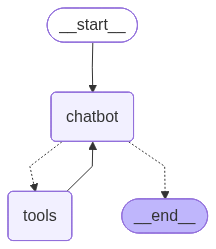

In [34]:
from IPython.display import display, Image

Image(financial_analyst_agent.get_graph().draw_mermaid_png())

## Test the Agent

In [35]:
from IPython.display import display, Markdown

response = llm.invoke('what is the PE ratio of Nvidia?')
display(Markdown(response.content))

I currently don't have real-time data access to provide the current price-to-earnings (P/E) ratio for Nvidia or any other company. To find the most up-to-date P/E ratio for Nvidia, you can check financial news websites, stock market platforms, or financial services like Bloomberg, Yahoo Finance, or Google Finance. These platforms typically provide real-time stock data, including the P/E ratio.

In [36]:
def call_agent(agent, prompt, user_config={"configurable": {"thread_id": "any"}}):
    events = agent.stream(
        {"messages": [{"role": "user", "content": prompt}]},
        user_config,
        stream_mode="values",
    )

    for event in events:
        event["messages"][-1].pretty_print()

    print()
    print('Final Response:\n')
    display(Markdown(event["messages"][-1].content))

In [42]:
query = 'How is Nvidia doing and it is worth investing in it or its competitors?'
call_agent(financial_analyst_agent, query)

================================ Human Message =================================

How is Nvidia doing and it is worth investing in it or its competitors?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (call_jwEmTV32X5GHTbfPTl1oORWy)
 Call ID: call_jwEmTV32X5GHTbfPTl1oORWy
  Args:
    stock_name: Nvidia
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |
================================== Ai Message ==================================
Tool Calls:
  get_stock_price_metrics (call_zISPxiUvPRfd7Xbu1Pu07TyR)
 Call ID: call_zISPxiUvPRfd7Xbu1Pu07TyR
  Args:
    stock_ticker: NVDA
  get_stock_fundamental_indicator_metrics (call_xJp7oarUrY9FCe0oCBOhdr3Q)
 Call ID: call_xJp7oarUr

Here's a detailed overview of NVIDIA Corporation (symbol: NVDA) and some insights into the current market trends:

### NVIDIA Corporation (NVDA)
- **Current Price**: \$190.17
- **Price Change**: +\$3.31 (1.77%)
- **Volume**: 186,591,856 shares
- **Market Cap**: \$4.63 trillion
- **52-Week High/Low**: \$212.19 / \$86.62
- **PE Forward**: 46.16
- **EPS (TTM)**: \$3.52
- **EPS Forward**: \$4.12
- **Dividend Yield**: 0.0214%

### General Market Data
- **Most Actively Traded Stocks**: NVIDIA, Opendoor Technologies, Tesla, Pfizer, BigBear.ai
- **Top Price Gainers**: Scholar Rock Holding, Legence Corp., Cytek Biosciences
- **Top Price Losers**: Avient Corporation, Federal Agricultural Mortgage, Scotts Miracle-Gro

### News and Insights
Unfortunately, I couldn't retrieve the latest news articles for NVIDIA, but you can check financial news websites for the most recent updates.

### Investment Consideration
NVIDIA is currently performing well with a strong market cap and positive price movement. However, its PE forward ratio is relatively high, indicating that the stock might be overvalued compared to its earnings. It's essential to consider the competitive landscape, including companies like AMD and Intel, which are also key players in the semiconductor industry.

### Recommendations
- **NVIDIA**: Strong performance but consider the high valuation.
- **Competitors**: Look into AMD and Intel for potential investment opportunities.

Please ensure to conduct your own research or consult with a financial advisor before making any investment decisions.

In [19]:
query = 'what is the PE ratio of Nvidia?'
call_agent(financial_analyst_agent, query)

================================ Human Message =================================

what is the PE ratio of Nvidia?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (call_wZTqLEpNYVrta4T3cNmIoCzR)
 Call ID: call_wZTqLEpNYVrta4T3cNmIoCzR
  Args:
    stock_name: Nvidia
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |
================================== Ai Message ==================================
Tool Calls:
  get_stock_fundamental_indicator_metrics (call_C9Us85uwt0JolBLTEFqjVPcc)
 Call ID: call_C9Us85uwt0JolBLTEFqjVPcc
  Args:
    stock_ticker: NVDA
================================= Tool Message =================================
Name: get_stock_fundamental_indicator_met

The PE ratio for Nvidia (symbol: NVDA) is currently 46.62. This metric is a key indicator used by investors to evaluate the valuation of a company relative to its earnings. Please let me know if you need more information!

In [20]:
query = 'what is the PE ratio of Intel?'
call_agent(financial_analyst_agent, query)

================================ Human Message =================================

what is the PE ratio of Intel?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (call_r1P1tHEFF9ZpF4gzkwLnFWjT)
 Call ID: call_r1P1tHEFF9ZpF4gzkwLnFWjT
  Args:
    stock_name: Intel
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name                                                           |     cik |
|---:|:---------|:---------------------------------------------------------------|--------:|
|  0 | INTC     | INTEL CORP                                                     |   50863 |
|  1 | CCCS     | CCC Intelligent Solutions Holdings Inc.                        | 1818201 |
|  2 | ZK       | ZEEKR Intelligent Technology Holding Ltd                       | 1954042 |
|  3 | NTLA     | Intel

The PE ratio for Intel Corporation (symbol: INTC) as of the latest available data is approximately 21.51.

In [21]:
query = 'which is better?'
call_agent(financial_analyst_agent, query)

================================ Human Message =================================

which is better?
================================== Ai Message ==================================

It seems like your question is incomplete. Are you asking about a comparison between two specific stocks or companies? If so, please provide the names or ticker symbols of the companies you're interested in. Alternatively, if you're looking for general advice on the stock market or specific metrics, please let me know so I can assist you accordingly!

Final Response:



It seems like your question is incomplete. Are you asking about a comparison between two specific stocks or companies? If so, please provide the names or ticker symbols of the companies you're interested in. Alternatively, if you're looking for general advice on the stock market or specific metrics, please let me know so I can assist you accordingly!

In [22]:
query = 'Get detailed information of how Nvidia and Intel are doing and do a comparative analysis of which stock might be better?'
call_agent(financial_analyst_agent, query)

================================ Human Message =================================

Get detailed information of how Nvidia and Intel are doing and do a comparative analysis of which stock might be better?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (call_U4htf7NuD99m9AZzNODJsjPt)
 Call ID: call_U4htf7NuD99m9AZzNODJsjPt
  Args:
    stock_name: Nvidia
  get_stock_ticker_symbol (call_eP6E71HDAVfm6obDbWKjbuat)
 Call ID: call_eP6E71HDAVfm6obDbWKjbuat
  Args:
    stock_name: Intel
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name                                                           |     cik |
|---:|:---------|:---------------------------------------------------------------|--------:|
|  0 | INTC     | INTEL CORP                                                     | 

Here's a detailed comparative analysis of Nvidia (NVDA) and Intel (INTC) based on the latest available data:

### Nvidia (NVDA)
- **Market Cap**: \$2.9 trillion
- **PE Ratio**: 46.62
- **Forward PE**: 26.63
- **PEG Ratio (TTM)**: 1.022
- **Price to Book Ratio**: 67.90
- **Price to Sales Ratio**: 25.32
- **Price to Free Cash Flows Ratio**: 57.08
- **Price to Operating Cash Flows Ratio**: 54.91
- **Dividend Yield**: 0.03%
- **Revenue Growth**: 122.4%
- **Earnings Growth**: 168%
- **Gross Margin**: 75.98%
- **Operating Margin**: 62.06%
- **Profit Margin**: 55.04%
- **Return on Assets**: 55.26%
- **Return on Equity**: 123.77%
- **Current Price**: \$118.42 (as of the last trading day)
- **52-Week High/Low**: \$153.13/\$60.70

### Intel (INTC)
- **Market Cap**: \$87.51 billion
- **Forward PE**: 21.51
- **PEG Ratio (TTM)**: 0.618
- **Price to Book Ratio**: 0.88
- **Price to Sales Ratio**: 3.88
- **Price to Free Cash Flows Ratio**: -14.75
- **Price to Operating Cash Flows Ratio**: 18.35
- **Dividend Yield**: 2.24%
- **Revenue Growth**: -6.2%
- **Gross Margin**: 40.07%
- **Operating Margin**: -1.05%
- **Profit Margin**: -29.42%
- **Return on Assets**: -0.26%
- **Return on Equity**: -15.60%
- **Current Price**: \$20.29 (as of the last trading day)
- **52-Week High/Low**: \$46.63/\$18.51

### Comparative Analysis
- **Growth and Profitability**: Nvidia shows strong growth and profitability metrics, with high revenue and earnings growth, and robust margins. Intel, on the other hand, is experiencing negative growth and profitability, with negative operating and profit margins.
- **Valuation**: Nvidia's valuation ratios are significantly higher, reflecting its growth potential and market position. Intel's lower valuation ratios may indicate a more value-oriented investment, but also reflect its current challenges.
- **Dividend Yield**: Intel offers a higher dividend yield, which may appeal to income-focused investors.
- **Risk and Volatility**: Nvidia has a higher beta (1.657) compared to Intel (1.026), indicating higher volatility.

### Conclusion
Nvidia appears to be a better choice for growth-oriented investors, given its strong financial performance and growth prospects. Intel may appeal to value investors looking for a turnaround story, but it currently faces significant challenges. As always, it's important to conduct your own research and consider your investment goals and risk tolerance before making any investment decisions.

We have successfully built an AI Agent which can do detailed financial analysis for us but it is not yet conversational. We will add in the that functionality in the next videos